In [1]:
#import the libaries to work with for EDA
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
#loading the data set
data = pd.read_csv("C:\\Users\\Vikas Bhilatiya\\Desktop\\Data\\Online Payment Fraud Detection.csv")

# UNDERSTANDING THE DATA

In [4]:
# Checking the size of the dataset (Rows,Columns)
data.shape

(1048575, 10)

In [5]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


In [6]:
data.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
1048570,95,CASH_OUT,132557.35,C1179511630,479803.00,347245.65,C435674507,484329.37,616886.72,0
1048571,95,PAYMENT,9917.36,C1956161225,90545.00,80627.64,M668364942,0.00,0.00,0
1048572,95,PAYMENT,14140.05,C2037964975,20545.00,6404.95,M1355182933,0.00,0.00,0
1048573,95,PAYMENT,10020.05,C1633237354,90605.00,80584.95,M1964992463,0.00,0.00,0
1048574,95,PAYMENT,11450.03,C1264356443,80584.95,69134.92,M677577406,0.00,0.00,0


In [7]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,2.696617e+01,1.586670e+05,8.740095e+05,8.938089e+05,9.781600e+05,1.114198e+06,1.089097e-03
std,1.562325e+01,2.649409e+05,2.971751e+06,3.008271e+06,2.296780e+06,2.416593e+06,3.298351e-02
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.500000e+01,1.214907e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+01,7.634333e+04,1.600200e+04,0.000000e+00,1.263772e+05,2.182604e+05,0.000000e+00
75%,3.900000e+01,2.137619e+05,1.366420e+05,1.746000e+05,9.159235e+05,1.149808e+06,0.000000e+00
max,9.500000e+01,1.000000e+07,3.890000e+07,3.890000e+07,4.210000e+07,4.220000e+07,1.000000e+00


In [8]:
data.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='object')

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  object 
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  object 
 4   oldbalanceOrg   1048575 non-null  float64
 5   newbalanceOrig  1048575 non-null  float64
 6   nameDest        1048575 non-null  object 
 7   oldbalanceDest  1048575 non-null  float64
 8   newbalanceDest  1048575 non-null  float64
 9   isFraud         1048575 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 80.0+ MB


In [10]:
data.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
dtype: object

In [11]:
#check for missing Data using isna().sum()

data.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [12]:
#Checking which recipients stand out

data.nameDest.unique()

array(['M1979787155', 'M2044282225', 'C553264065', ..., 'M1355182933',
       'M1964992463', 'M677577406'], dtype=object)

In [13]:
#Investigating to check unique customers
data.nameOrig.unique()

array(['C1231006815', 'C1666544295', 'C1305486145', ..., 'C2037964975',
       'C1633237354', 'C1264356443'], dtype=object)

In [14]:
#investigating to see how many times a customer started a transaction
data.nameOrig.value_counts()

nameOrig
C1214450722    2
C309111136     2
C1268675361    2
C720460198     2
C1109092856    2
              ..
C560131732     1
C455251560     1
C650578540     1
C1883668225    1
C1264356443    1
Name: count, Length: 1048317, dtype: int64

In [15]:
#How many times a recipient got a transaction
data.nameDest.value_counts()

nameDest
C985934102     98
C1286084959    96
C1590550415    89
C248609774     88
C665576141     87
               ..
M382871047      1
M322765556      1
M1118794441     1
M1127250627     1
M677577406      1
Name: count, Length: 449635, dtype: int64

In [16]:
data.amount.max()

10000000.0

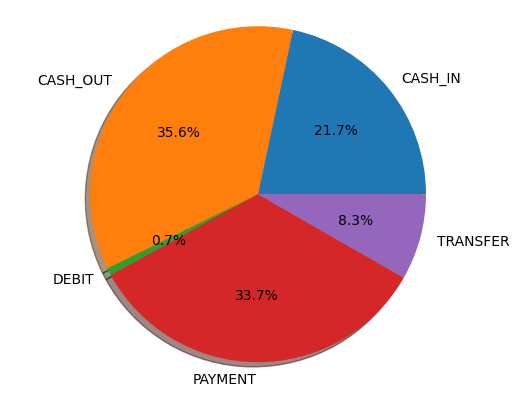

In [17]:
#Checking the distribution of the type of transactions made

labels = data['type'].astype('category').cat.categories.tolist()
counts = data['type'].value_counts()
sizes = [counts[var_cat] for var_cat in labels]
fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', shadow=True) #autopct is show the % on plot
ax1.axis('equal')
plt.show()

In [18]:
#Investigating how many times a particular type of transaction was carried out. 

data.type.value_counts()

type
CASH_OUT    373641
PAYMENT     353873
CASH_IN     227130
TRANSFER     86753
DEBIT         7178
Name: count, dtype: int64

In [19]:
#Investigating the top customers and the type of transactions they initiated
top_ten = data.groupby('nameOrig').type.sum().sort_values(ascending=False)[:10]
top_ten

nameOrig
C24957224      TRANSFERTRANSFER
C1378765159    TRANSFERTRANSFER
C813633808     TRANSFERTRANSFER
C940075559     TRANSFERTRANSFER
C1709295811     TRANSFERPAYMENT
C196315367      TRANSFERPAYMENT
C1077087409     TRANSFERPAYMENT
C495164373      TRANSFERPAYMENT
C192628069      TRANSFERPAYMENT
C1039623203     TRANSFERPAYMENT
Name: type, dtype: object

In [20]:
#Checking the average amounttransacted
data['amount'].mean()

158666.9755271392

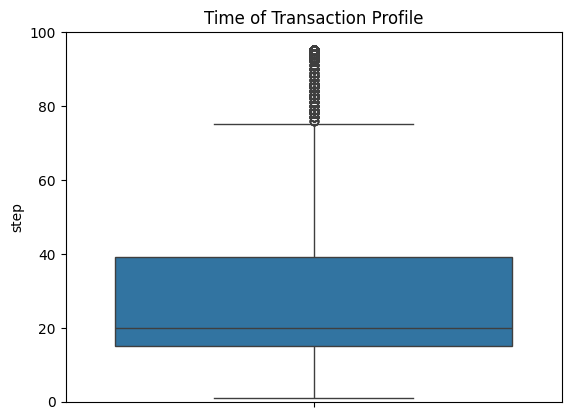

In [21]:
sns.boxplot(y=data.step)
plt.title('Time of Transaction Profile')
plt.ylim(0,100)
plt.show()

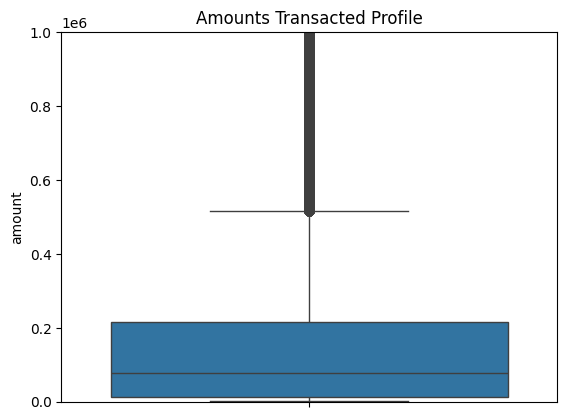

In [22]:
sns.boxplot(y=data.amount)
plt.title('Amounts Transacted Profile')
plt.ylim(0,1000000)
plt.show()

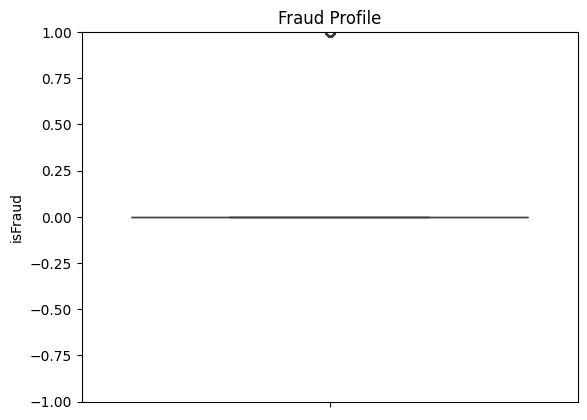

In [23]:
sns.boxplot(y=data.isFraud)
plt.title('Fraud Profile')
plt.ylim(-1,1)
plt.show()

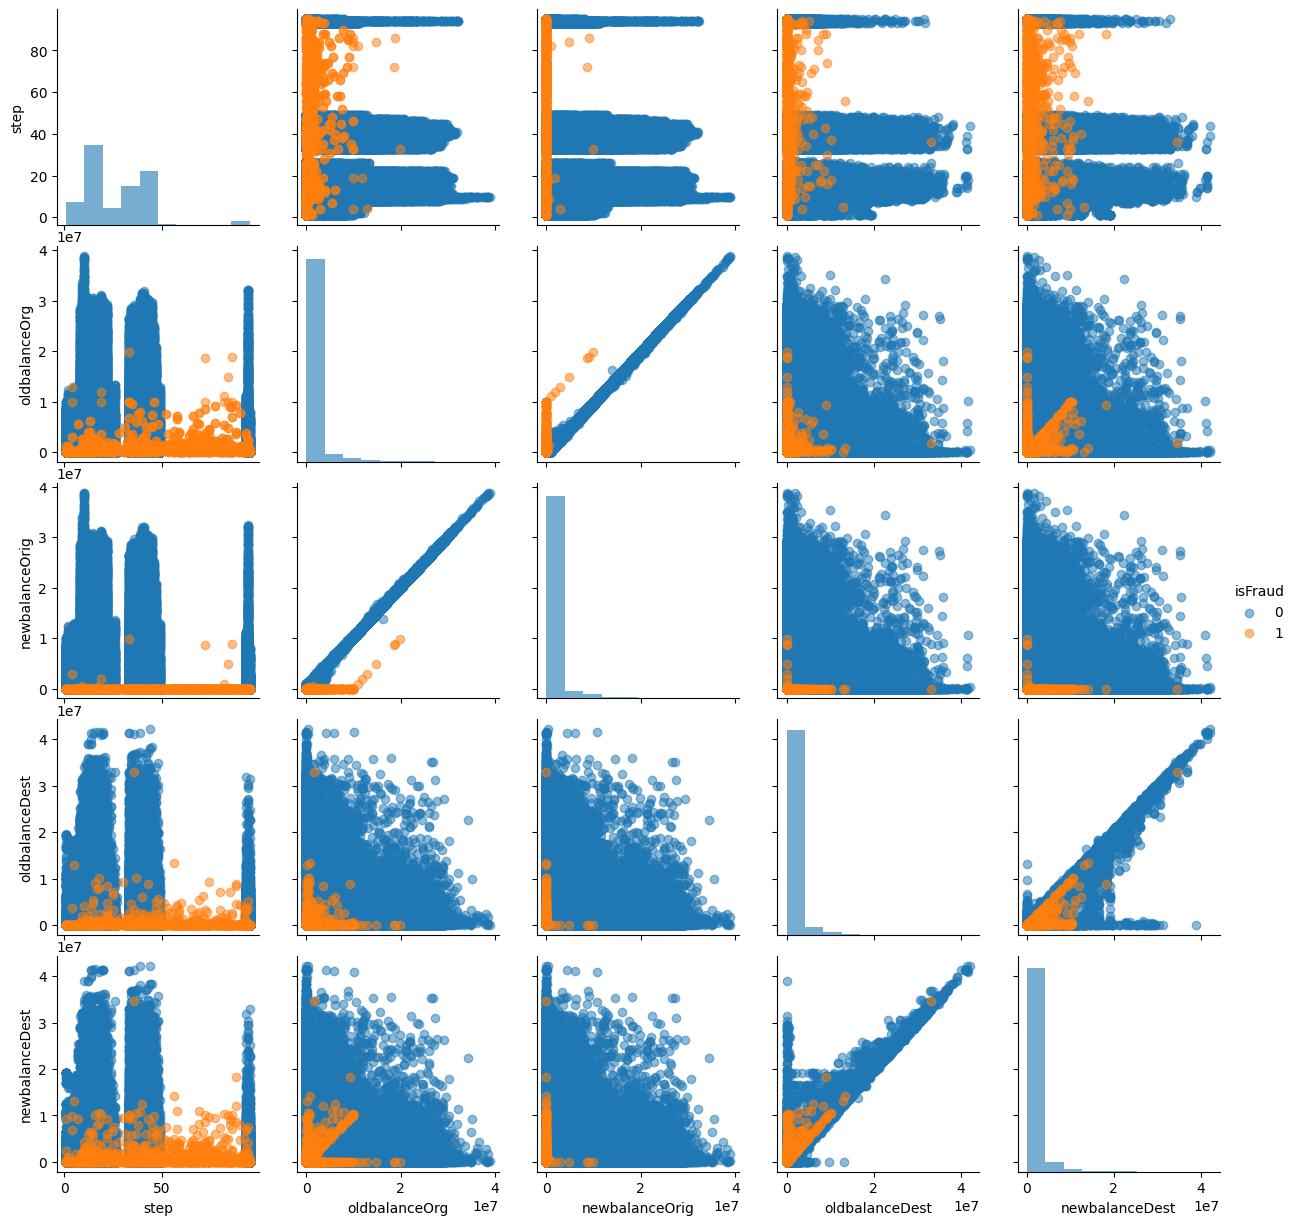

In [24]:
#Visualising the spread of fraud variables across the dataset

Online_Payment_layout = sns.PairGrid(data, vars = ['step', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'], hue = 'isFraud')

Online_Payment_layout.map_diag(plt.hist, alpha = 0.6)
Online_Payment_layout.map_offdiag(plt.scatter, alpha = 0.5)
Online_Payment_layout.add_legend()

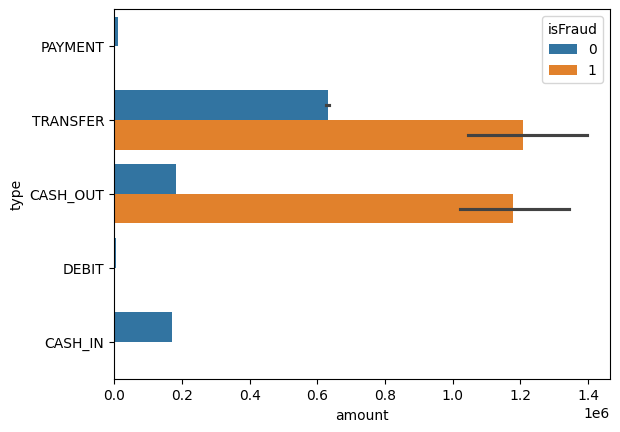

In [25]:
sns.barplot(x='amount', y='type', hue= 'isFraud', data=data)
plt.show()

(0.0, 2000000.0)

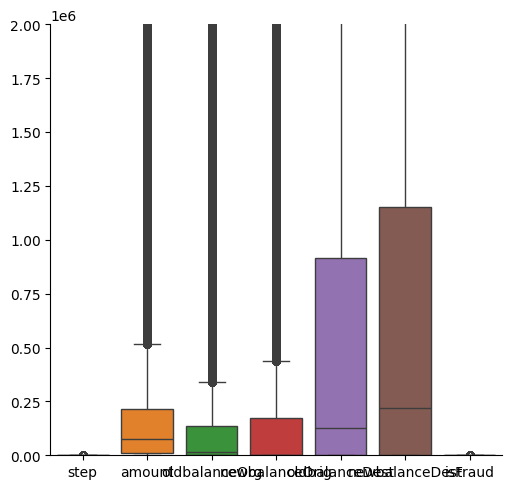

In [26]:
sns.catplot(data=data,kind='box')

plt.ylim(0,2000000)

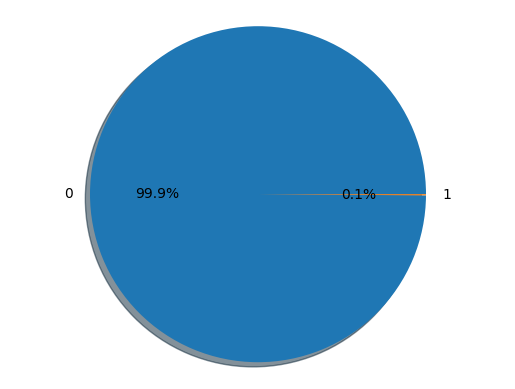

In [27]:
# Fraud Distribution

labels = data['isFraud'].astype('category').cat.categories.tolist()
counts = data['isFraud'].value_counts()
sizes = [counts[var_cat] for var_cat in labels]
fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', shadow=True) #autopct is show the % on plot
ax1.axis('equal')
plt.show()

In [28]:
# Sepearating Fraudulent transaction from non fraudulent

Fraudulent_Transaction = data[data.isFraud ==1]
Not_Fraudulent_Transaction = data[data.isFraud ==0]

In [29]:
print('Fraudulent Transaction: {}'.format(len(Fraudulent_Transaction)))
print('Not Fraudulent Transaction: {}'.format(len(Not_Fraudulent_Transaction)))

Fraudulent Transaction: 1142
Not Fraudulent Transaction: 1047433


In [30]:
#Understanding The statistical nature of Non Fraudulent Transactions.

Not_Fraudulent_Transaction.amount.describe()

count    1.047433e+06
mean     1.575397e+05
std      2.541883e+05
min      1.000000e-01
25%      1.213487e+04
50%      7.621497e+04
75%      2.134928e+05
max      6.419835e+06
Name: amount, dtype: float64

In [31]:

#Understanding The statistical nature of Fraudulent Transactions.

Fraudulent_Transaction.amount.describe()

count    1.142000e+03
mean     1.192629e+06
std      2.030599e+06
min      1.190000e+02
25%      8.607017e+04
50%      3.531794e+05
75%      1.248759e+06
max      1.000000e+07
Name: amount, dtype: float64

In [33]:

#Comparing both class of transactions
data.groupby('isFraud').mean(numeric_only=True)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
isFraud,,,,,,
0,26.942944,1.575397e+05,8.736338e+05,894746.395080,978732.769117,1.114237e+06
1,48.272329,1.192629e+06,1.218636e+06,33944.321208,452866.124527,1.077940e+06


# UNDERSAMPLING

In [34]:
Non_Fraudulent_Sample = Not_Fraudulent_Transaction.sample(n=1142)

In [35]:
new_dataset = pd.concat([Non_Fraudulent_Sample, Fraudulent_Transaction], axis=0)

In [36]:
new_dataset.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
840478,41,CASH_OUT,205070.94,C363534733,0.00,0.0,C155518158,536090.98,741161.92,0
931780,43,PAYMENT,13437.39,C2051419517,11990.00,0.0,M1775058257,0.00,0.00,0
373255,17,CASH_IN,317688.59,C1383091790,8594463.61,8912152.2,C790614131,869414.31,551725.72,0
274105,15,CASH_OUT,40268.40,C1788096672,201.00,0.0,C501040800,1335312.63,1375581.03,0
308968,16,CASH_OUT,201473.64,C1688019582,0.00,0.0,C1926343982,625136.35,826609.99,0


In [37]:
new_dataset.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
1047888,95,CASH_OUT,56745.14,C526144262,56745.14,0.0,C79051264,51433.88,108179.02,1
1048221,95,TRANSFER,33676.59,C732111322,33676.59,0.0,C1140210295,0.00,0.00,1
1048222,95,CASH_OUT,33676.59,C1000086512,33676.59,0.0,C1759363094,0.00,33676.59,1
1048323,95,TRANSFER,87999.25,C927181710,87999.25,0.0,C757947873,0.00,0.00,1
1048324,95,CASH_OUT,87999.25,C409531429,87999.25,0.0,C1827219533,0.00,87999.25,1


In [38]:

new_dataset['isFraud'].value_counts()

isFraud
0    1142
1    1142
Name: count, dtype: int64

In [39]:
new_dataset.shape

(2284, 10)

In [41]:
#Checking to see if the new dataset we obtained is a good i.e does not deviate significantly from our original dataset
new_dataset.groupby('isFraud').mean(numeric_only=True)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
isFraud,,,,,,
0,26.600701,1.521109e+05,8.696712e+05,888456.663494,1.042140e+06,1.160171e+06
1,48.272329,1.192629e+06,1.218636e+06,33944.321208,4.528661e+05,1.077940e+06


# FEATURE ENGINEERING

In [42]:
# One-hot Encoding.
#Importing library

from sklearn.preprocessing import OneHotEncoder

In [45]:
#creating instance of one-hot-encoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop=None)

In [46]:
#perform one-hot encoding on 'type' column 
encoder_df =  pd.get_dummies(new_dataset, columns=['type','nameOrig','nameDest'], prefix=['type','nameOrig','nameDest'])

In [47]:
encoder_df

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,...,nameDest_M945272763,nameDest_M947435104,nameDest_M949115496,nameDest_M953074700,nameDest_M960544974,nameDest_M962686973,nameDest_M96411388,nameDest_M970355825,nameDest_M972031269,nameDest_M984545107
840478,41,205070.94,0.00,0.0,536090.98,741161.92,0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
931780,43,13437.39,11990.00,0.0,0.00,0.00,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
373255,17,317688.59,8594463.61,8912152.2,869414.31,551725.72,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
274105,15,40268.40,201.00,0.0,1335312.63,1375581.03,0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
308968,16,201473.64,0.00,0.0,625136.35,826609.99,0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1047888,95,56745.14,56745.14,0.0,51433.88,108179.02,1,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1048221,95,33676.59,33676.59,0.0,0.00,0.00,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1048222,95,33676.59,33676.59,0.0,0.00,33676.59,1,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1048323,95,87999.25,87999.25,0.0,0.00,0.00,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [48]:
encoder_df.shape

(2284, 4555)

In [49]:
# Check result of one-hot encoding
encoder_df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,...,nameDest_M945272763,nameDest_M947435104,nameDest_M949115496,nameDest_M953074700,nameDest_M960544974,nameDest_M962686973,nameDest_M96411388,nameDest_M970355825,nameDest_M972031269,nameDest_M984545107
840478,41,205070.94,0.00,0.0,536090.98,741161.92,0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
931780,43,13437.39,11990.00,0.0,0.00,0.00,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
373255,17,317688.59,8594463.61,8912152.2,869414.31,551725.72,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
274105,15,40268.40,201.00,0.0,1335312.63,1375581.03,0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
308968,16,201473.64,0.00,0.0,625136.35,826609.99,0,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [50]:
encoder_df.tail()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,...,nameDest_M945272763,nameDest_M947435104,nameDest_M949115496,nameDest_M953074700,nameDest_M960544974,nameDest_M962686973,nameDest_M96411388,nameDest_M970355825,nameDest_M972031269,nameDest_M984545107
1047888,95,56745.14,56745.14,0.0,51433.88,108179.02,1,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1048221,95,33676.59,33676.59,0.0,0.00,0.00,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1048222,95,33676.59,33676.59,0.0,0.00,33676.59,1,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1048323,95,87999.25,87999.25,0.0,0.00,0.00,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1048324,95,87999.25,87999.25,0.0,0.00,87999.25,1,False,True,False,...,False,False,False,False,False,False,False,False,False,False


# TARGET, FEATURE SPLIT

In [51]:
Y = encoder_df['isFraud']

In [52]:

features = encoder_df.drop('isFraud', axis=1)

In [53]:
X = features

In [54]:
Y.head()

840478    0
931780    0
373255    0
274105    0
308968    0
Name: isFraud, dtype: int64

In [55]:

X.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,...,nameDest_M945272763,nameDest_M947435104,nameDest_M949115496,nameDest_M953074700,nameDest_M960544974,nameDest_M962686973,nameDest_M96411388,nameDest_M970355825,nameDest_M972031269,nameDest_M984545107
840478,41,205070.94,0.00,0.0,536090.98,741161.92,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
931780,43,13437.39,11990.00,0.0,0.00,0.00,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
373255,17,317688.59,8594463.61,8912152.2,869414.31,551725.72,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
274105,15,40268.40,201.00,0.0,1335312.63,1375581.03,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
308968,16,201473.64,0.00,0.0,625136.35,826609.99,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [56]:
from sklearn.model_selection import train_test_split

In [57]:
#create X_train, X_test, Y_train, Y_test
# using test_size of 20%

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, stratify=Y, random_state=2)

In [58]:
print('\n',X_train.head(2))

print('\n',X_test.head(2))

print('\n',Y_train.head(2))

print('\n',Y_test.head(2))


          step     amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
1030484    67  106460.70       106460.7            0.00      1414263.15   
308891     16   10098.36       101029.0        90930.64            0.00   

         newbalanceDest  type_CASH_IN  type_CASH_OUT  type_DEBIT  \
1030484      1520723.84         False           True       False   
308891             0.00         False          False       False   

         type_PAYMENT  ...  nameDest_M945272763  nameDest_M947435104  \
1030484         False  ...                False                False   
308891           True  ...                False                False   

         nameDest_M949115496  nameDest_M953074700  nameDest_M960544974  \
1030484                False                False                False   
308891                 False                False                False   

         nameDest_M962686973  nameDest_M96411388  nameDest_M970355825  \
1030484                False               False      

# Training our Classification Model with a Logistic Regression Classifier

In [59]:
from sklearn.linear_model import LogisticRegression

In [60]:
model = LogisticRegression()

In [61]:
#Training model with Training data
model.fit(X_train, Y_train)

C:\Users\Vikas Bhilatiya\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [62]:
model_pred = model.predict(X_test)

In [63]:
# Obtain model probabilities
probs = model.predict_proba(X_test)

# Logistic Regression Model Evaluation

In [64]:
#importing the methods
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, precision_recall_curve, average_precision_score, roc_auc_score

In [65]:
print('\nClassification Report:')
print(classification_report(Y_test, model_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       229
           1       0.91      0.91      0.91       228

    accuracy                           0.91       457
   macro avg       0.91      0.91      0.91       457
weighted avg       0.91      0.91      0.91       457



In [66]:
# check True Negatives/Positives, False Negatives/Positives
pd.DataFrame(confusion_matrix(Y_test, model_pred), 
             columns=['Predicted Negative(0) ', 'Predicted Positive(1)'], 
             index=['Actually Negative(0)', 'Actually Positive(1)'])

,Predicted Negative(0),Predicted Positive(1)
Actually Negative(0),208,21
Actually Positive(1),20,208


In [67]:
# Print confusion matrix using predictions in context 
pd.DataFrame(confusion_matrix(Y_test, model_pred), 
             columns=['Predicted Not Fraud(0) ', 'Predicted Fraud(1)'], 
             index=['Actually Not Fraud(0)', 'Actually Fraud(1)'])

,Predicted Not Fraud(0),Predicted Fraud(1)
Actually Not Fraud(0),208,21
Actually Fraud(1),20,208


In [68]:
# ACCURACY SCORE
print('Accuracy:',accuracy_score(Y_test, model_pred))

Accuracy: 0.9102844638949672


In [69]:
# Calculate average precision and the P-R curve
average_precision = average_precision_score(Y_test, model_pred)
average_precision

0.8723854489213392

In [70]:
#define metrics
y_pred_proba = model.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(Y_test,  y_pred_proba)
auc = metrics.roc_auc_score(Y_test, y_pred_proba)

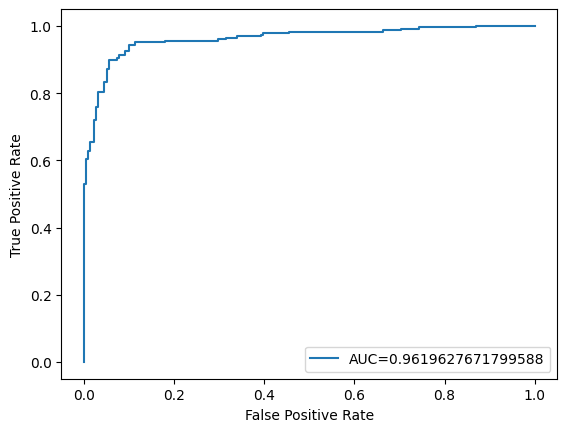

In [71]:
#create ROC curve
plt.plot(fpr,tpr,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()

In [72]:
print('AUC Score:')
print(roc_auc_score(Y_test, probs[:,1]))

AUC Score:
0.9619627671799588


# Training with Random Forest Classifier

In [73]:
from sklearn.ensemble import RandomForestClassifier

In [74]:
# Define the model as the random forest
model = RandomForestClassifier(random_state=5, n_estimators=20)

In [75]:
model.fit(X_train,Y_train)

RandomForestClassifier(n_estimators=20, random_state=5)

In [76]:
model_pred = model.predict(X_test)

In [77]:
# Obtain model probabilities
probs = model.predict_proba(X_test)

# Random Forest Model Evaluation

In [78]:
#importing the methods
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, precision_recall_curve, average_precision_score, roc_auc_score

In [79]:
# Print classification report using predictions
print('Classification_Report:\n',classification_report(Y_test, model_pred))

Classification_Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95       229
           1       0.97      0.94      0.95       228

    accuracy                           0.95       457
   macro avg       0.95      0.95      0.95       457
weighted avg       0.95      0.95      0.95       457



In [80]:
# Print confusion matrix using predictions
pd.DataFrame(confusion_matrix(Y_test, model_pred), 
             columns=['Predicted Negative(0) ', 'Predicted Positive(1)'], 
             index=['Actually Negative(0)', 'Actually Positive(1)'])

,Predicted Negative(0),Predicted Positive(1)
Actually Negative(0),222,7
Actually Positive(1),14,214


In [81]:
# Print confusion matrix using predictions in Context
pd.DataFrame(confusion_matrix(Y_test, model_pred), 
             columns=['Predicted Not Fraud(0) ', 'Predicted Fraud(1)'], 
             index=['Actually Not Fraud(0)', 'Actually Fraud(1)'])

,Predicted Not Fraud(0),Predicted Fraud(1)
Actually Not Fraud(0),222,7
Actually Fraud(1),14,214


In [82]:

# ACCURACY SCORE
print('Accuracy:',accuracy_score(Y_test, model_pred))

Accuracy: 0.9540481400437637


In [83]:
# Calculate average precision and the P-R curve
average_precision = average_precision_score(Y_test, model_pred)
average_precision

0.9395017639050943

In [84]:
#define metrics
y_pred_proba = model.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(Y_test,  y_pred_proba)
auc = metrics.roc_auc_score(Y_test, y_pred_proba)

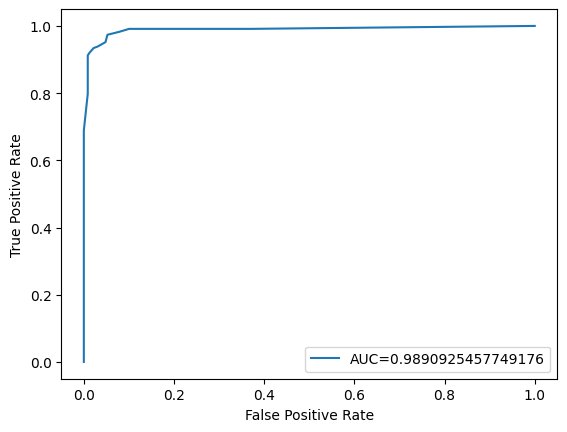

In [85]:
#create ROC curve
plt.plot(fpr,tpr,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()

In [86]:
# Print ROC_AUC score using probabilities
print('AUC Score:')
print(roc_auc_score(Y_test, probs[:, 1]))

AUC Score:
0.9890925457749176
